In [1]:
import numpy as np
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer
import random

# Generate synthetic data for two users
data = {
    "user": [],
    "text": []
}

user_texts = {
    "user_1": [
        "The quick brown fox jumps over the lazy dog",
        "I enjoy hiking during the weekend",
        "Python programming is fun and rewarding"
    ],
    "user_2": [
        "A journey of a thousand miles begins with a single step",
        "He who learns but does not think, is lost",
        "To be or not to be, that is the question"
    ]
}

# Generate samples
for user, texts in user_texts.items():
    for _ in range(50):
        text = random.choice(texts)
        data["user"].append(user)
        data["text"].append(text)

# Convert to DataFrame
df = pd.DataFrame(data)

# Feature extraction with TF-IDF
vectorizer = TfidfVectorizer(max_features=50)
X = vectorizer.fit_transform(df["text"]).toarray()
y = np.array([1 if user == "user_1" else 0 for user in df["user"]])

print("Feature matrix shape:", X.shape)
print("Labels shape:", y.shape)


Feature matrix shape: (100, 39)
Labels shape: (100,)


In [2]:
import tensorflow as tf
from tensorflow.keras import layers, models

# Define Autoencoder Model
input_dim = X.shape[1]
encoding_dim = 16  # Dimension of the encoded representation

input_layer = layers.Input(shape=(input_dim,))
encoded = layers.Dense(encoding_dim, activation='relu')(input_layer)
decoded = layers.Dense(input_dim, activation='sigmoid')(encoded)

autoencoder = models.Model(inputs=input_layer, outputs=decoded)

# Compile the model
autoencoder.compile(optimizer='adam', loss='mse')

# Train the model
autoencoder.fit(X, X, epochs=50, batch_size=8, shuffle=True, validation_split=0.2)


Epoch 1/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 0.2103 - val_loss: 0.2033
Epoch 2/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.2053 - val_loss: 0.1990
Epoch 3/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.2003 - val_loss: 0.1946
Epoch 4/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.1951 - val_loss: 0.1897
Epoch 5/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.1894 - val_loss: 0.1840
Epoch 6/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.1830 - val_loss: 0.1773
Epoch 7/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.1744 - val_loss: 0.1696
Epoch 8/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.1644 - val_loss: 0.1605
Epoch 9/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.1577 - val_loss: 0.1504
Epoch 10/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.1434 - val_loss: 0.1384
Epoch 11/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.1319 - val_loss: 0.1254
Epoch 12/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.1181 - val_l

In [3]:
# Extract encoded features
encoder = models.Model(inputs=input_layer, outputs=encoded)
encoded_X = encoder.predict(X)

# Mean of the encoded features for user_1 (assuming user_1 is the genuine user)
genuine_user_mean = np.mean(encoded_X[y == 1], axis=0)

# Authentication function
def authenticate(text):
    vectorized_text = vectorizer.transform([text]).toarray()
    encoded_text = encoder.predict(vectorized_text)
    distance = np.linalg.norm(encoded_text - genuine_user_mean)
    threshold = 0.5  # Set a threshold for authentication
    return distance < threshold

# Test the authentication function
test_text = "I enjoy a good hike during weekends"
is_authenticated = authenticate(test_text)

if is_authenticated:
    print("Access Granted")
else:
    print("Access Denied")


4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
Access Denied


In [6]:
import numpy as np
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer
import random
import tensorflow as tf
from tensorflow.keras import layers, models

# Generate synthetic data for two users
data = {
    "user": [],
    "text": []
}

user_texts = {
    "user_1": [
        "The quick brown fox jumps over the lazy dog",
        "I enjoy hiking during the weekend",
        "Python programming is fun and rewarding"
    ],
    "user_2": [
        "A journey of a thousand miles begins with a single step",
        "He who learns but does not think, is lost",
        "To be or not to be, that is the question"
    ]
}

# Generate samples
for user, texts in user_texts.items():
    for _ in range(50):
        text = random.choice(texts)
        data["user"].append(user)
        data["text"].append(text)

# Convert to DataFrame
df = pd.DataFrame(data)

# Feature extraction with TF-IDF
vectorizer = TfidfVectorizer(max_features=50)
X = vectorizer.fit_transform(df["text"]).toarray()
y = np.array([1 if user == "user_1" else 0 for user in df["user"]])

# Define Autoencoder Model
input_dim = X.shape[1]
encoding_dim = 16  # Dimension of the encoded representation

input_layer = layers.Input(shape=(input_dim,))
encoded = layers.Dense(encoding_dim, activation='relu')(input_layer)
decoded = layers.Dense(input_dim, activation='sigmoid')(encoded)

autoencoder = models.Model(inputs=input_layer, outputs=decoded)

# Compile the model
autoencoder.compile(optimizer='adam', loss='mse')

# Train the model
autoencoder.fit(X, X, epochs=50, batch_size=8, shuffle=True, validation_split=0.2)

# Extract encoded features
encoder = models.Model(inputs=input_layer, outputs=encoded)
encoded_X = encoder.predict(X)

# Mean of the encoded features for user_1 (assuming user_1 is the genuine user)
genuine_user_mean = np.mean(encoded_X[y == 1], axis=0)

# Authentication function
def authenticate(text):
    vectorized_text = vectorizer.transform([text]).toarray()
    encoded_text = encoder.predict(vectorized_text)
    distance = np.linalg.norm(encoded_text - genuine_user_mean)
    threshold = 0.5  # Set a threshold for authentication
    return distance < threshold

# Test the authentication function
test_text = "I enjoy a good hike during weekends"
is_authenticated = authenticate(test_text)

if is_authenticated:
    print("Access Granted")
else:
    print("Access Denied")


Epoch 1/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 0.2102 - val_loss: 0.2029
Epoch 2/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.2048 - val_loss: 0.1979
Epoch 3/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.1996 - val_loss: 0.1928
Epoch 4/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.1949 - val_loss: 0.1875
Epoch 5/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.1892 - val_loss: 0.1817
Epoch 6/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.1810 - val_loss: 0.1751
Epoch 7/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.1734 - val_loss: 0.1673
Epoch 8/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.1623 - val_loss: 0.1585
Epoch 9/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.1537 - val_loss: 0.1481
Epoch 10/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.1416 - val_loss: 0.1364
Epoch 11/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.1272 - val_loss: 0.1237
Epoch 12/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.1169 - val_l

In [11]:
# Extract encoded features
encoder = models.Model(inputs=input_layer, outputs=encoded)
encoded_X = encoder.predict(X)

# Mean of the encoded features for user_1 (assuming user_1 is the genuine user)
genuine_user_mean = np.mean(encoded_X[y == 1], axis=0)

# Authentication function with distance printing
def authenticate(text):
    vectorized_text = vectorizer.transform([text]).toarray()
    encoded_text = encoder.predict(vectorized_text)
    distance = np.linalg.norm(encoded_text - genuine_user_mean)
    print(f"Distance: {distance}")
    threshold = 0.3  # Adjusted threshold for better accuracy
    return distance < threshold

# Test the authentication function with a text
test_text = "I enjoy spending time with my family on weekends"
is_authenticated = authenticate(test_text)

if is_authenticated:
    print("Access Granted")
else:
    print("Access Denied")


4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step 
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
Distance: 1.2581313848495483
Access Denied


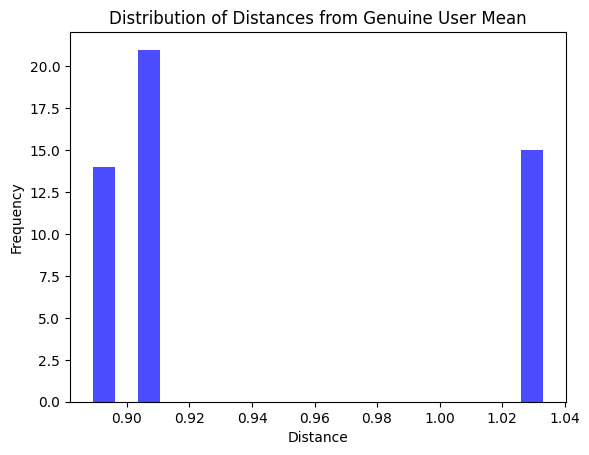

In [12]:
import matplotlib.pyplot as plt

# Calculate distances for all genuine user's texts
distances = np.linalg.norm(encoded_X[y == 1] - genuine_user_mean, axis=1)

# Plot the distribution of distances
plt.hist(distances, bins=20, alpha=0.7, color='blue')
plt.title("Distribution of Distances from Genuine User Mean")
plt.xlabel("Distance")
plt.ylabel("Frequency")
plt.show()


In [13]:
from sklearn.preprocessing import StandardScaler

# Normalize the TF-IDF vectors
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


In [14]:
autoencoder.fit(X_scaled, X_scaled, epochs=100, batch_size=16, shuffle=True, validation_split=0.2)


Epoch 1/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.9558 - val_loss: 0.9621
Epoch 2/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.8920 - val_loss: 0.9302
Epoch 3/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.8433 - val_loss: 0.9057
Epoch 4/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.7940 - val_loss: 0.8803
Epoch 5/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.8207 - val_loss: 0.8581
Epoch 6/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.7938 - val_loss: 0.8358
Epoch 7/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.7591 - val_loss: 0.8100
Epoch 8/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.7021 - val_loss: 0.7828
Epoch 9/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.6847 - val_loss: 0.7544
Epoch 10/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.6211 - val_loss: 0.7261
Epoch 11/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.6367 - val_loss: 0.6981
Epoch 12/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.6244 - val_loss: 0.6716

In [15]:
# Define a deeper Autoencoder Model
input_dim = X.shape[1]
encoding_dim = 32  # Dimension of the encoded representation

input_layer = layers.Input(shape=(input_dim,))
encoded = layers.Dense(64, activation='relu')(input_layer)
encoded = layers.Dense(encoding_dim, activation='relu')(encoded)
decoded = layers.Dense(64, activation='relu')(encoded)
decoded = layers.Dense(input_dim, activation='sigmoid')(decoded)

autoencoder = models.Model(inputs=input_layer, outputs=decoded)

# Compile the model
autoencoder.compile(optimizer='adam', loss='mse')

# Train the model with more epochs
autoencoder.fit(X_scaled, X_scaled, epochs=100, batch_size=16, shuffle=True, validation_split=0.2)


Epoch 1/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step - loss: 1.2465 - val_loss: 1.2443
Epoch 2/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 1.2178 - val_loss: 1.2062
Epoch 3/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 1.1586 - val_loss: 1.1726
Epoch 4/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 1.1274 - val_loss: 1.1315
Epoch 5/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 1.0833 - val_loss: 1.0834
Epoch 6/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 1.0523 - val_loss: 1.0271
Epoch 7/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.9693 - val_loss: 0.9685
Epoch 8/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.8845 - val_loss: 0.9049
Epoch 9/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.8136 - val_loss: 0.8413
Epoch 10/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.7448 - val_loss: 0.7807
Epoch 11/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.6481 - val_loss: 0.7195
Epoch 12/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.5861 - val_loss: 0.6591


2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step


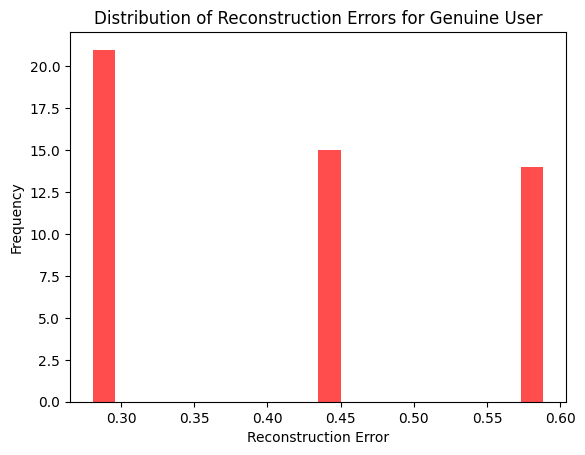

In [16]:
# Calculate reconstruction error for genuine user
reconstructions = autoencoder.predict(X_scaled[y == 1])
reconstruction_errors = np.mean(np.square(reconstructions - X_scaled[y == 1]), axis=1)

# Plot the distribution of reconstruction errors
plt.hist(reconstruction_errors, bins=20, alpha=0.7, color='red')
plt.title("Distribution of Reconstruction Errors for Genuine User")
plt.xlabel("Reconstruction Error")
plt.ylabel("Frequency")
plt.show()


In [17]:
def authenticate(text):
    vectorized_text = vectorizer.transform([text]).toarray()
    vectorized_text_scaled = scaler.transform(vectorized_text)
    encoded_text = encoder.predict(vectorized_text_scaled)
    distance = np.linalg.norm(encoded_text - genuine_user_mean)
    print(f"Distance: {distance}")
    threshold = 0.01  # Start with a small threshold and adjust
    return distance < threshold

# Test the authentication function with a text
test_text = "I enjoy spending time with my family on weekends"
is_authenticated = authenticate(test_text)

if is_authenticated:
    print("Access Granted")
else:
    print("Access Denied")


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
Distance: 5.259124755859375
Access Denied


Feature matrix shape: (400, 102)
Labels shape: (400,)
Epoch 1/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 0.2407 - val_loss: 0.2220
Epoch 2/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.2162 - val_loss: 0.1811
Epoch 3/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.1713 - val_loss: 0.1194
Epoch 4/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.1085 - val_loss: 0.0721
Epoch 5/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0657 - val_loss: 0.0612
Epoch 6/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0538 - val_loss: 0.0611
Epoch 7/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0532 - val_loss: 0.0610
Epoch 8/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0532 - val_loss: 0.0607
Epoch 9/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0516 - val_loss: 0.0605
Epoch 10/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0513 - val_loss: 0.0601
Epoch 11/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0515 - val_loss: 0.0595
Epoch 12

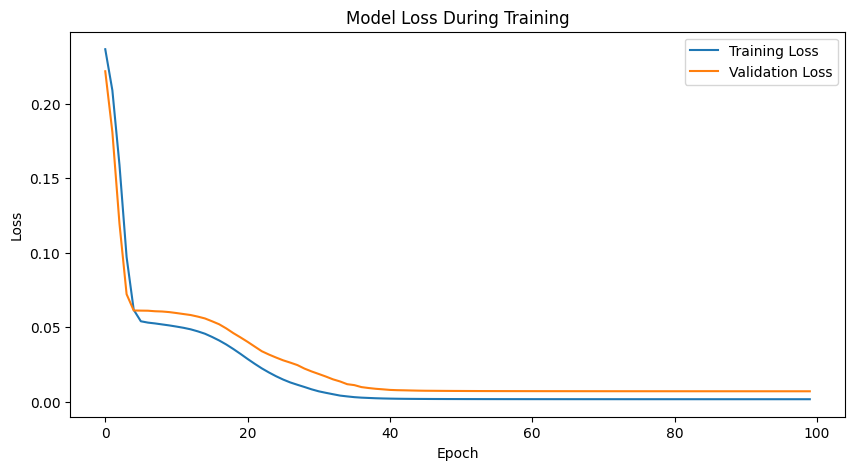

13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 


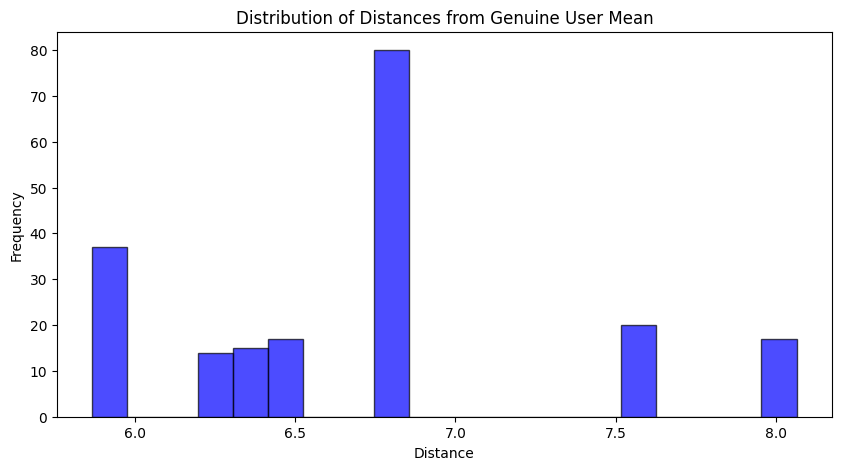

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step


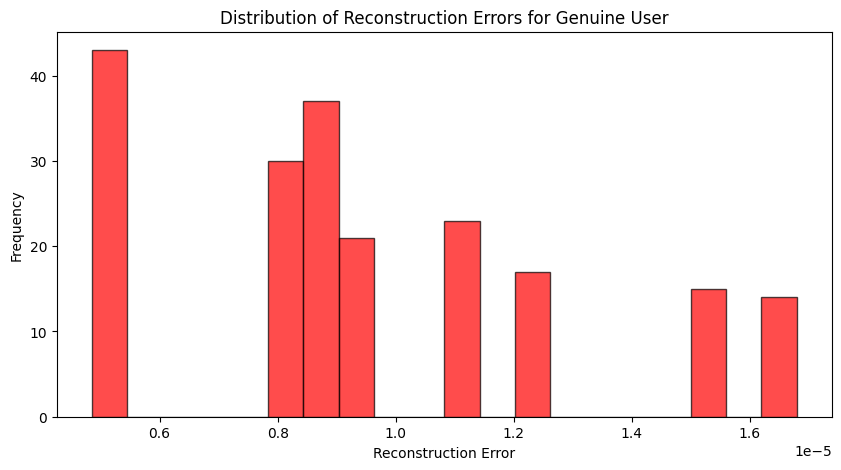

Testing text: "I enjoy spending time with my family on weekends"
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
Distance: 6.314279079437256
Access Denied

Testing text: "He who thinks great thoughts, often makes great errors"
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
Distance: 6.6493940353393555
Access Denied

Testing text: "Cooking new recipes is exciting"
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step
Distance: 6.248251914978027
Access Denied

Testing text: "Art is a lie that makes us realize the truth"
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
Distance: 9.849319458007812
Access Denied



In [18]:
import numpy as np
import pandas as pd
import random
import tensorflow as tf
from tensorflow.keras import layers, models
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import MinMaxScaler
import matplotlib.pyplot as plt

# 1. Dataset Preparation with a Larger Dataset and MinMax Scaling

# Generate synthetic data for two users with more diversity
data = {
    "user": [],
    "text": []
}

user_texts = {
    "user_1": [
        "The quick brown fox jumps over the lazy dog",
        "I enjoy hiking during the weekend",
        "Python programming is fun and rewarding",
        "My favorite color is blue",
        "Reading books expands my mind",
        "I love spending time with my family",
        "Exercising regularly keeps me healthy",
        "Cooking new recipes is exciting",
        "Listening to music relaxes me",
        "Traveling opens up new perspectives"
    ],
    "user_2": [
        "A journey of a thousand miles begins with a single step",
        "He who learns but does not think, is lost",
        "To be or not to be, that is the question",
        "Art is a lie that makes us realize the truth",
        "Patience is bitter, but its fruit is sweet",
        "Wisdom begins in wonder",
        "Knowledge speaks, but wisdom listens",
        "The pen is mightier than the sword",
        "Life is what happens when you're busy making other plans",
        "In the middle of difficulty lies opportunity"
    ]
}

# Generate more samples with varied data
for user, texts in user_texts.items():
    for _ in range(200):  # Increase the number of samples per user
        text = random.choice(texts)
        data["user"].append(user)
        data["text"].append(text)

# Convert to DataFrame
df = pd.DataFrame(data)

# Feature extraction with TF-IDF
vectorizer = TfidfVectorizer(max_features=200)  # Increase the feature size for better representation
X = vectorizer.fit_transform(df["text"]).toarray()
y = np.array([1 if user == "user_1" else 0 for user in df["user"]])

print("Feature matrix shape:", X.shape)
print("Labels shape:", y.shape)

# Normalize the TF-IDF vectors using MinMaxScaler
scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X)

# 2. Autoencoder Model with Adjustments

# Define a deeper Autoencoder Model
input_dim = X_scaled.shape[1]
encoding_dim = 32  # Dimension of the encoded representation

input_layer = layers.Input(shape=(input_dim,))
encoded = layers.Dense(64, activation='relu')(input_layer)
encoded = layers.Dense(encoding_dim, activation='relu')(encoded)
decoded = layers.Dense(64, activation='relu')(encoded)
decoded = layers.Dense(input_dim, activation='sigmoid')(decoded)

autoencoder = models.Model(inputs=input_layer, outputs=decoded)

# Compile the model
autoencoder.compile(optimizer='adam', loss='mse')

# Train the model with more epochs
history = autoencoder.fit(
    X_scaled, X_scaled,
    epochs=100,
    batch_size=32,
    shuffle=True,
    validation_split=0.2,
    verbose=1
)

# Plot training & validation loss values
plt.figure(figsize=(10,5))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss During Training')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(loc='upper right')
plt.show()

# 3. Extract Encoded Features

# Create the encoder model
encoder = models.Model(inputs=input_layer, outputs=encoded)

# Encode all samples
encoded_X = encoder.predict(X_scaled)

# Mean of the encoded features for user_1 (assuming user_1 is the genuine user)
genuine_user_mean = np.mean(encoded_X[y == 1], axis=0)

# 4. Analyze Distances for Genuine Users

# Calculate distances for all genuine user's texts
distances = np.linalg.norm(encoded_X[y == 1] - genuine_user_mean, axis=1)

# Plot the distribution of distances
plt.figure(figsize=(10,5))
plt.hist(distances, bins=20, alpha=0.7, color='blue', edgecolor='black')
plt.title("Distribution of Distances from Genuine User Mean")
plt.xlabel("Distance")
plt.ylabel("Frequency")
plt.show()

# 5. Check Reconstruction Error for Genuine User

reconstructions = autoencoder.predict(X_scaled[y == 1])
reconstruction_errors = np.mean(np.square(reconstructions - X_scaled[y == 1]), axis=1)

# Plot the distribution of reconstruction errors
plt.figure(figsize=(10,5))
plt.hist(reconstruction_errors, bins=20, alpha=0.7, color='red', edgecolor='black')
plt.title("Distribution of Reconstruction Errors for Genuine User")
plt.xlabel("Reconstruction Error")
plt.ylabel("Frequency")
plt.show()

# 6. Authentication Mechanism with Distance Printing and Adjusted Threshold

# Define the authentication function
def authenticate(text, threshold=0.5):
    vectorized_text = vectorizer.transform([text]).toarray()
    vectorized_text_scaled = scaler.transform(vectorized_text)
    encoded_text = encoder.predict(vectorized_text_scaled)
    distance = np.linalg.norm(encoded_text - genuine_user_mean)
    print(f"Distance: {distance}")
    return distance < threshold

# Test the authentication function with various texts
test_texts = [
    "I enjoy spending time with my family on weekends",
    "He who thinks great thoughts, often makes great errors",
    "Cooking new recipes is exciting",
    "Art is a lie that makes us realize the truth"
]

threshold = 0.5  # Adjust this based on distance distribution

for text in test_texts:
    print(f"Testing text: \"{text}\"")
    is_authenticated = authenticate(text, threshold)
    if is_authenticated:
        print("Access Granted\n")
    else:
        print("Access Denied\n")


7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 


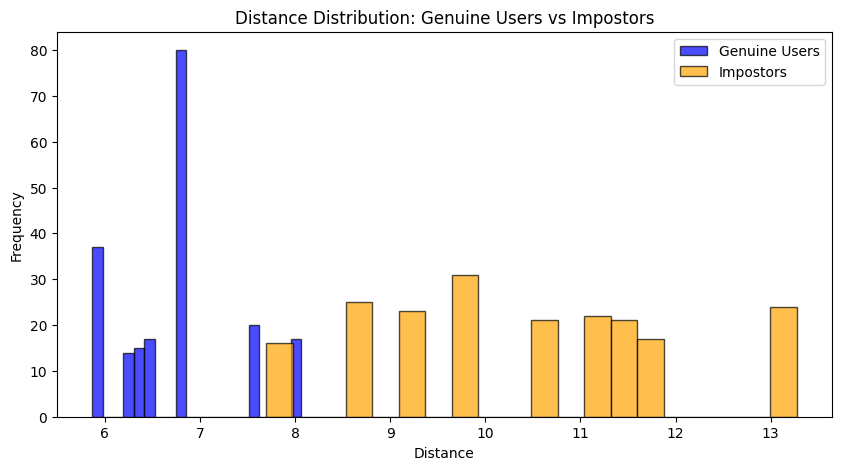

Testing text: "I enjoy spending time with my family on weekends"
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
Distance: 6.314279079437256
Access Denied

Testing text: "He who thinks great thoughts, often makes great errors"
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
Distance: 6.6493940353393555
Access Denied

Testing text: "Cooking new recipes is exciting"
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
Distance: 6.248251914978027
Access Denied

Testing text: "Art is a lie that makes us realize the truth"
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
Distance: 9.849319458007812
Access Denied



In [19]:
# 7. Threshold Calibration with Impostor Samples

# Generate impostor samples (user_2)
impostor_indices = np.where(y == 0)[0]
impostor_X_scaled = X_scaled[impostor_indices]
impostor_encoded_X = encoder.predict(impostor_X_scaled)

# Calculate distances for impostors
impostor_distances = np.linalg.norm(impostor_encoded_X - genuine_user_mean, axis=1)

# Plot distance distributions for genuine users and impostors
plt.figure(figsize=(10,5))
plt.hist(distances, bins=20, alpha=0.7, color='blue', label='Genuine Users', edgecolor='black')
plt.hist(impostor_distances, bins=20, alpha=0.7, color='orange', label='Impostors', edgecolor='black')
plt.title("Distance Distribution: Genuine Users vs Impostors")
plt.xlabel("Distance")
plt.ylabel("Frequency")
plt.legend()
plt.show()

# Choose a threshold that separates genuine and impostor distances
# For example, set the threshold where genuine distances are mostly below and impostor distances are above
threshold = 1.0  # Adjust based on the plotted distribution

# Update the authenticate function
def authenticate(text, threshold=1.0):
    vectorized_text = vectorizer.transform([text]).toarray()
    vectorized_text_scaled = scaler.transform(vectorized_text)
    encoded_text = encoder.predict(vectorized_text_scaled)
    distance = np.linalg.norm(encoded_text - genuine_user_mean)
    print(f"Distance: {distance}")
    return distance < threshold

# Test the authentication function with genuine and impostor texts
test_texts = [
    "I enjoy spending time with my family on weekends",  # Genuine
    "He who thinks great thoughts, often makes great errors",  # Impostor
    "Cooking new recipes is exciting",  # Genuine
    "Art is a lie that makes us realize the truth"  # Impostor
]

for text in test_texts:
    print(f"Testing text: \"{text}\"")
    is_authenticated = authenticate(text, threshold)
    if is_authenticated:
        print("Access Granted\n")
    else:
        print("Access Denied\n")
